# Sweeps → labeled datasets

The core mushin move: define a `task(**config)`, sweep it over a grid with
`multirun`, and get the results back as a **labeled `xarray.Dataset`** whose
dimensions are exactly the parameters you swept. No manual bookkeeping of runs.

Here we train a tiny logistic-regression classifier on a fixed synthetic
2-class problem across a grid of **learning rates × seeds**, record training
accuracy, and read the result as a dataset with dims `(lr, seed)`.

In [ ]:
from __future__ import annotations

import tempfile

import torch as tr

from mushin import multirun
from mushin.workflows import MultiRunMetricsWorkflow

A fixed, seeded synthetic dataset — two Gaussian blobs, one per class.

In [ ]:
POINTS_PER_CLASS = 256


def make_data(seed: int, n: int = POINTS_PER_CLASS):
    g = tr.Generator().manual_seed(seed)
    x0 = tr.randn(n, 2, generator=g) + tr.tensor([2.0, 2.0])
    x1 = tr.randn(n, 2, generator=g) + tr.tensor([-2.0, -2.0])
    x = tr.cat([x0, x1])
    y = tr.cat([tr.zeros(n), tr.ones(n)])
    return x, y

The workflow: subclass `MultiRunMetricsWorkflow` and implement `task`. Whatever
`dict` it returns becomes variables in the dataset.

In [ ]:
class LRSweep(MultiRunMetricsWorkflow):
    @staticmethod
    def task(lr: float, seed: int) -> dict:
        tr.manual_seed(seed)
        x, y = make_data(seed)
        model = tr.nn.Linear(2, 1)
        opt = tr.optim.SGD(model.parameters(), lr=lr)
        for _ in range(100):
            opt.zero_grad()
            logits = model(x).squeeze(1)
            tr.nn.functional.binary_cross_entropy_with_logits(logits, y).backward()
            opt.step()
        with tr.no_grad():
            acc = ((model(x).squeeze(1) > 0).float() == y).float().mean().item()
        return dict(accuracy=acc)

Run the `lr × seed` sweep with `multirun(...)` and read it back as a dataset.

In [ ]:
wf = LRSweep()
wf.run(
    lr=multirun([0.01, 0.1, 1.0]),
    seed=multirun([0, 1, 2]),
    working_dir=tempfile.mkdtemp(),
)
ds = wf.to_xarray()
ds

[2026-07-14 20:30:31,406][HYDRA] Launching 9 jobs locally


[2026-07-14 20:30:31,406][HYDRA] 	#0 : +lr=0.01 +seed=0


[2026-07-14 20:30:31,536][HYDRA] 	#1 : +lr=0.01 +seed=1


[2026-07-14 20:30:31,611][HYDRA] 	#2 : +lr=0.01 +seed=2


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(


...

[2026-07-14 20:30:31,964][HYDRA] 	#7 : +lr=1.0 +seed=1


[2026-07-14 20:30:32,036][HYDRA] 	#8 : +lr=1.0 +seed=2


/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  r

/Users/josuemartinez/code/mushin/.venv/lib/python3.10/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(


<xarray.Dataset> Size: 120B
Dimensions:   (lr: 3, seed: 3)
Coordinates:
  * lr        (lr) float64 24B 0.01 0.1 1.0
  * seed      (seed) int64 24B 0 1 2
Data variables:
    accuracy  (lr, seed) float64 72B 0.9863 0.9824 0.998 ... 0.9941 0.9961 1.0
Attributes:
    provenance:  {"timestamp": "2026-07-15T00:30:31.448850+00:00", "python": ...

The dataset is fully labeled — reduce over `seed` to get mean accuracy per
learning rate.

In [ ]:
mean_acc = ds["accuracy"].mean("seed")
mean_acc

<xarray.DataArray 'accuracy' (lr: 3)> Size: 24B
array([0.98893229, 0.99739583, 0.99674479])
Coordinates:
  * lr       (lr) float64 24B 0.01 0.1 1.0

And the payoff: a metric-vs-parameter curve with the per-seed spread.

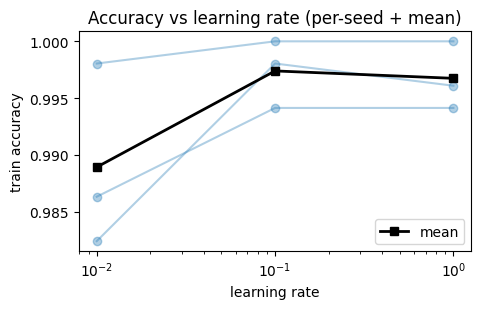

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.2))
for s in ds["seed"].values:
    ax.plot(
        ds["lr"].values,
        ds["accuracy"].sel(seed=s).values,
        "o-",
        alpha=0.35,
        color="tab:blue",
    )
ax.plot(ds["lr"].values, mean_acc.values, "ks-", lw=2, label="mean")
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("train accuracy")
ax.set_title("Accuracy vs learning rate (per-seed + mean)")
ax.legend()
fig.tight_layout()
plt.show()

**See also**

- [Workflows & sweeps guide](../guides/workflows.md) — the full sweep API.
- [Notebook 06](06_sklearn_framework_agnostic.ipynb) — the same flow with a
  scikit-learn model (no torch): the sweep layer is framework-agnostic.